## 1. Load the Dataset

We load the CSV file using pandas to begin our analysis.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../../data/raw/studentRegistration.csv')
print('Dataset loaded successfully')

Dataset loaded successfully


## 2. Dataset Shape and Column Names

Understanding the dimensions of the dataset helps us know how many rows (samples) and columns (features) we have.


In [ ]:
print(f'Dataset shape: {df.shape}')
print(f'\nNumber of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')
print(f'\nColumn names:')
print(df.columns.tolist())

Dataset shape: (32593, 5)

Number of rows: 32593
Number of columns: 5

Column names:
['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']


## 3. Preview First and Last Rows

Examining the first and last rows gives us a sense of the data content and structure.


In [ ]:
print('First 5 rows:')
print(df.head())
print('\n' + '='*80 + '\n')
print('Last 5 rows:')
print(df.tail())

First 5 rows:
  code_module code_presentation  id_student  date_registration  \
0         AAA             2013J       11391             -159.0   
1         AAA             2013J       28400              -53.0   
2         AAA             2013J       30268              -92.0   
3         AAA             2013J       31604              -52.0   
4         AAA             2013J       32885             -176.0   

   date_unregistration  
0                  NaN  
1                  NaN  
2                 12.0  
3                  NaN  
4                  NaN  


Last 5 rows:
      code_module code_presentation  id_student  date_registration  \
32588         GGG             2014J     2640965               -4.0   
32589         GGG             2014J     2645731              -23.0   
32590         GGG             2014J     2648187             -129.0   
32591         GGG             2014J     2679821              -49.0   
32592         GGG             2014J     2684003              -28.0   

   

## 4. Data Types

Knowing the data type of each column is crucial for determining appropriate analysis and preprocessing techniques.


In [ ]:
print('Data types:')
print(df.dtypes)

Data types:
code_module                str
code_presentation          str
id_student               int64
date_registration      float64
date_unregistration    float64
dtype: object


## 5. Missing Value Analysis

Identifying missing values helps us understand data quality and determine handling strategies. We check both count and percentage of missing values.


In [ ]:
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) == 0:
    print('No missing values found in the dataset.')
else:
    print('Missing values:')
    print(missing_data)

Missing values:
                     Missing_Count  Missing_Percentage
date_unregistration          22521           69.097659
date_registration               45            0.138066


## 6. Duplicate Row Check

Duplicates can distort our analysis. We check for completely identical rows and rows with duplicate key identifiers.


In [ ]:
# Check for completely duplicate rows
total_duplicates = df.duplicated().sum()
print(f'Total completely duplicate rows: {total_duplicates}')
print(f'Percentage of duplicates: {(total_duplicates / len(df)) * 100:.2f}%')

# Check for duplicates in each column
print('\nDuplicate counts per column:')
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    if dup_count > 0:
        print(f'{col}: {dup_count} duplicates ({(dup_count/len(df))*100:.2f}%)')

Total completely duplicate rows: 0
Percentage of duplicates: 0.00%

Duplicate counts per column:
code_module: 32586 duplicates (99.98%)
code_presentation: 32589 duplicates (99.99%)
id_student: 3808 duplicates (11.68%)
date_registration: 32260 duplicates (98.98%)
date_unregistration: 32176 duplicates (98.72%)


## 7. Summary Statistics for Numeric Columns

Descriptive statistics provide insights into the distribution, central tendency, and spread of numeric features.


In [ ]:
print('Summary statistics for numeric columns:')
print(df.describe())

Summary statistics for numeric columns:
         id_student  date_registration  date_unregistration
count  3.259300e+04       32548.000000         10072.000000
mean   7.066877e+05         -69.411300            49.757645
std    5.491673e+05          49.260522            82.460890
min    3.733000e+03        -322.000000          -365.000000
25%    5.085730e+05        -100.000000            -2.000000
50%    5.903100e+05         -57.000000            27.000000
75%    6.444530e+05         -29.000000           109.000000
max    2.716795e+06         167.000000           444.000000


## 8. Overview of Categorical Columns

For categorical columns, we examine unique counts and sample values to understand categorical diversity.


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    for col in categorical_cols:
        print(f'{col}:')
        print(f'  Unique values: {df[col].nunique()}')
        print(f'  Sample values: {df[col].unique()}')
        print()
else:
    print('No categorical columns found in the dataset.')

code_module:
  Unique values: 7
  Sample values: <StringArray>
['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG']
Length: 7, dtype: str

code_presentation:
  Unique values: 4
  Sample values: <StringArray>
['2013J', '2014J', '2013B', '2014B']
Length: 4, dtype: str



C:\Users\Dell\AppData\Local\Temp\ipykernel_38392\3647526207.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## 9. Value Counts for Key Categorical or Target-like Columns

Detailed frequency analysis of categorical columns helps us identify class distributions and potential imbalances.


In [ ]:
for col in categorical_cols:
    print(f'Value counts for {col}:')
    print(df[col].value_counts())
    print(f'\nPercentage distribution:')
    print(df[col].value_counts(normalize=True) * 100)
    print('\n' + '='*80 + '\n')

Value counts for code_module:
code_module
BBB    7909
FFF    7762
DDD    6272
CCC    4434
EEE    2934
GGG    2534
AAA     748
Name: count, dtype: int64

Percentage distribution:
code_module
BBB    24.265947
FFF    23.814930
DDD    19.243396
CCC    13.604148
EEE     9.001933
GGG     7.774676
AAA     2.294971
Name: proportion, dtype: float64


Value counts for code_presentation:
code_presentation
2014J    11260
2013J     8845
2014B     7804
2013B     4684
Name: count, dtype: int64

Percentage distribution:
code_presentation
2014J    34.547295
2013J    27.137729
2014B    23.943792
2013B    14.371184
Name: proportion, dtype: float64




## 10. Registration Data Visualizations

Analyze registration patterns including missing unregistration dates and date distributions.


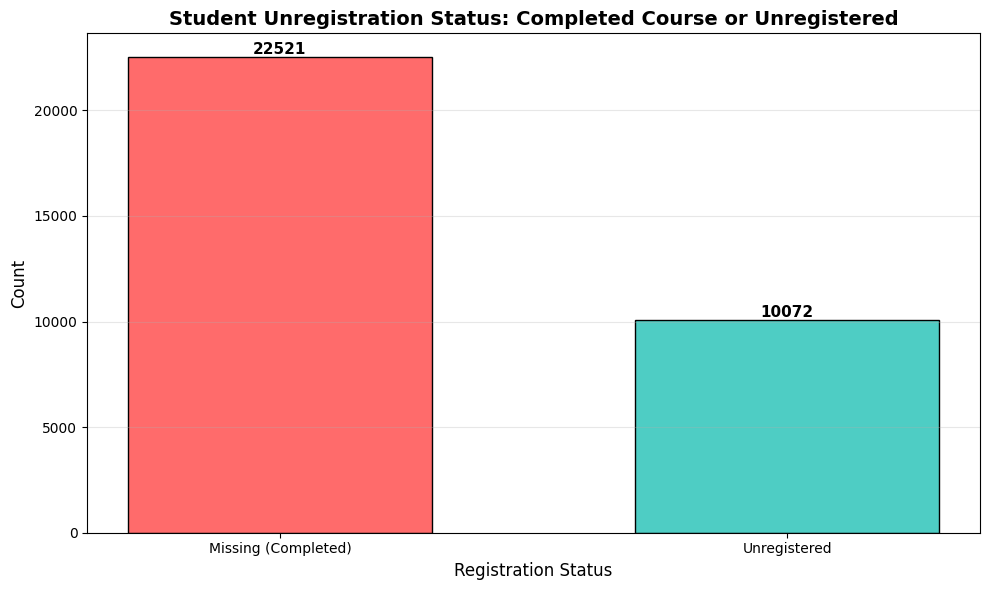


Student Registration Status:
Missing (Completed)    22521
Unregistered           10072
dtype: int64

Percentage Distribution:
Missing (Completed)    69.1
Unregistered           30.9
dtype: float64


In [ ]:
# 10.1: Count of students where date_unregistration is missing vs other values
fig, ax = plt.subplots(figsize=(10, 6))
unreg_status = pd.Series({
    'Missing (Completed)': df['date_unregistration'].isnull().sum(),
    'Unregistered': df['date_unregistration'].notnull().sum()
})

colors = ['#ff6b6b', '#4ecdc4']
ax.bar(unreg_status.index, unreg_status.values, color=colors, edgecolor='black', width=0.6)
ax.set_title('Student Unregistration Status: Completed Course or Unregistered', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Registration Status', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(unreg_status.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nStudent Registration Status:')
print(unreg_status)
print(f'\nPercentage Distribution:')
print((unreg_status / unreg_status.sum() * 100).round(2))

## 11. Date Distribution Analysis with Outliers

Box plots to visualize the distribution of registration and unregistration dates, highlighting outliers.


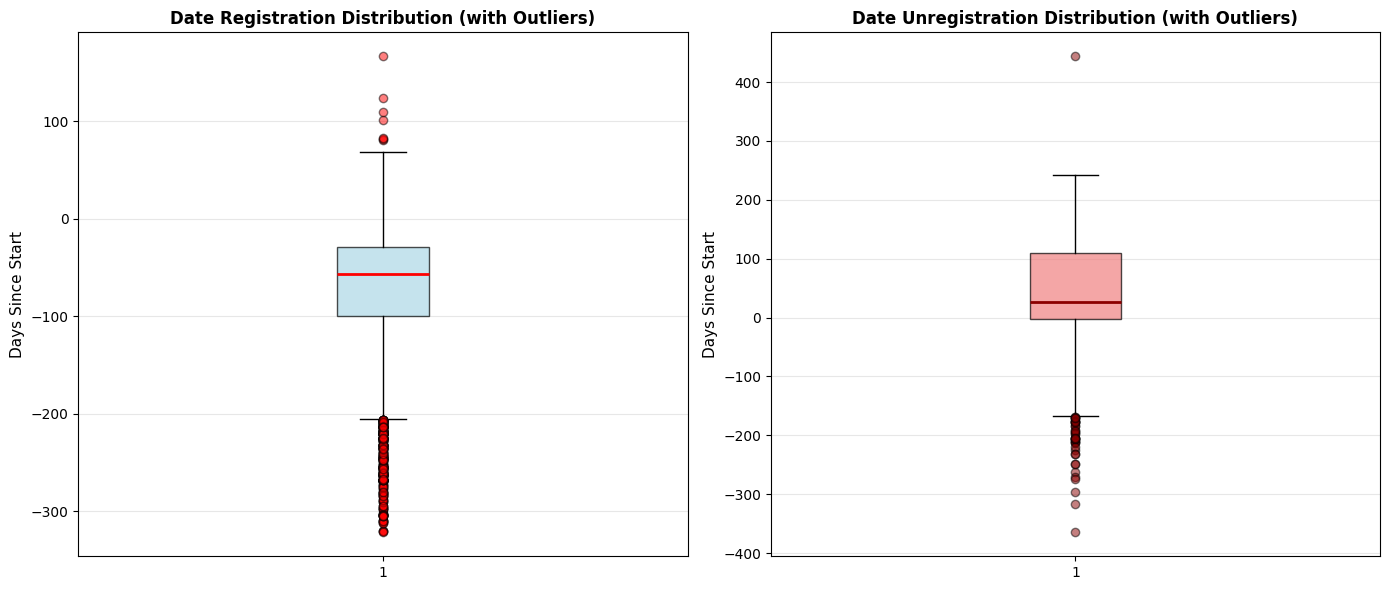


Date Registration Statistics:
count    32548.000000
mean       -69.411300
std         49.260522
min       -322.000000
25%       -100.000000
50%        -57.000000
75%        -29.000000
max        167.000000
Name: date_registration, dtype: float64


Date Unregistration Statistics (excluding missing):
count    10072.000000
mean        49.757645
std         82.460890
min       -365.000000
25%         -2.000000
50%         27.000000
75%        109.000000
max        444.000000
Name: date_unregistration, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot for date_registration
axes[0].boxplot(df['date_registration'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.5))
axes[0].set_title('Date Registration Distribution (with Outliers)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Days Since Start', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Box plot for date_unregistration (excluding missing values)
date_unreg_clean = df['date_unregistration'].dropna()
if len(date_unreg_clean) > 0:
    axes[1].boxplot(date_unreg_clean, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', alpha=0.7),
                    medianprops=dict(color='darkred', linewidth=2),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'),
                    flierprops=dict(marker='o', markerfacecolor='darkred', markersize=6, alpha=0.5))
    axes[1].set_title('Date Unregistration Distribution (with Outliers)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Days Since Start', fontsize=11)
    axes[1].grid(axis='y', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No unregistration dates available', ha='center', va='center', fontsize=12)
    axes[1].set_title('Date Unregistration Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nDate Registration Statistics:')
print(df['date_registration'].describe())
print('\n' + '='*80 + '\n')
print('Date Unregistration Statistics (excluding missing):')
if len(date_unreg_clean) > 0:
    print(date_unreg_clean.describe())
else:
    print('No unregistration dates available.')